In [1]:
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta
import pandas as pd
import numpy as np
import random
from pomelo.utils import Hal

/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/psycopg2/__init__.py:144: UserWarning: The psycopg2 wheel package will be renamed from release 2.8; in order to keep installing from binary please use "pip install psycopg2-binary" instead. For details see: <http://initd.org/psycopg/docs/install.html#binary-install-from-pypi>.
  """)


In [3]:
end_date = date.today().strftime("%Y-%m-%d")
six_months = date.today() - relativedelta(months=+6)
start_date = six_months.strftime("%Y-%m-%d")

In [4]:
end_date

'2021-09-20'

In [5]:
start_date

'2021-03-20'

In [7]:
hal = Hal()

# TH

In [8]:
sql_th = f"""
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week1' as week_id, 
net_units_sold_f1w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=0 AND DATEDIFF(day,dp.date_released,fs.order_date)<=6
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f1w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week2' as week_id,
net_units_sold_f2w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=7 AND DATEDIFF(day,dp.date_released,fs.order_date)<=13
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f2w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week3' as week_id, 
net_units_sold_f3w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=14 AND DATEDIFF(day,dp.date_released,fs.order_date)<=20
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f3w           
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week4' as week_id, 
net_units_sold_f4w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=21 AND DATEDIFF(day,dp.date_released,fs.order_date)<=27
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f4w    
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week5' as week_id, 
net_units_sold_f5w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=28 AND DATEDIFF(day,dp.date_released,fs.order_date)<=34
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f5w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week6' as week_id, 
net_units_sold_f6w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=35 AND DATEDIFF(day,dp.date_released,fs.order_date)<=41
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f6w  
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week7' as week_id, 
net_units_sold_f7w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=42 AND DATEDIFF(day,dp.date_released,fs.order_date)<=48
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f7w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week8' as week_id, 
net_units_sold_f8w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=49 AND DATEDIFF(day,dp.date_released,fs.order_date)<=55
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f8w   
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week9' as week_id, 
net_units_sold_f9w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=56 AND DATEDIFF(day,dp.date_released,fs.order_date)<=62
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f9w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week10' as week_id, 
net_units_sold_f10w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=63 AND DATEDIFF(day,dp.date_released,fs.order_date)<=69
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f10w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week11' as week_id, 
net_units_sold_f11w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=70 AND DATEDIFF(day,dp.date_released,fs.order_date)<=76
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f11w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week12' as week_id, 
net_units_sold_f12w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=77 AND DATEDIFF(day,dp.date_released,fs.order_date)<=83
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f12w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week13' as week_id, 
net_units_sold_f13w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=84 AND DATEDIFF(day,dp.date_released,fs.order_date)<=90
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f13w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week14' as week_id, 
net_units_sold_f14w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=91 AND DATEDIFF(day,dp.date_released,fs.order_date)<=97
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f14w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week15' as week_id, 
net_units_sold_f15w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=98 AND DATEDIFF(day,dp.date_released,fs.order_date)<=104
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f15w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week16' as week_id, 
net_units_sold_f16w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=105 AND DATEDIFF(day,dp.date_released,fs.order_date)<=111
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f16w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week17' as week_id, 
net_units_sold_f17w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released,fs.order_date)>=112 AND DATEDIFF(day,dp.date_released,fs.order_date)<=118
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f17w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop NOT IN (2,11,5)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
"""

In [9]:
size_dist_th = hal.get_pandas_df(sql_th)

In [10]:
size_dist_th

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold
0,134298,39692,S,TH,week1,2
1,141587,41982,M,TH,week1,13
2,133926,39606,XS,TH,week1,2
3,133934,39607,M,TH,week1,1
4,149643,45043,XL,TH,week1,1
...,...,...,...,...,...,...
70409,147776,44366,XL,TH,week17,0
70410,148376,44525,XXL,TH,week17,0
70411,140214,41501,XXL,TH,week17,0
70412,135946,40109,L,TH,week17,0


In [11]:
size_list = [
    "25",
    "26",
    "27",
    "28",
    "30",
    "32",
    "33",
    "34",
    "L",
    "M",
    "O",
    "S",
    "XL",
    "XS",
    "XXL",
]

In [12]:
size_dist_th = size_dist_th[size_dist_th["size"].isin(size_list)]
size_dist_th

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold
0,134298,39692,S,TH,week1,2
1,141587,41982,M,TH,week1,13
2,133926,39606,XS,TH,week1,2
3,133934,39607,M,TH,week1,1
4,149643,45043,XL,TH,week1,1
...,...,...,...,...,...,...
70409,147776,44366,XL,TH,week17,0
70410,148376,44525,XXL,TH,week17,0
70411,140214,41501,XXL,TH,week17,0
70412,135946,40109,L,TH,week17,0


# MY

In [13]:
sql_my = f"""
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week1' as week_id, 
net_units_sold_f1w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=0 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=6
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f1w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week2' as week_id,
net_units_sold_f2w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=7 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=13
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f2w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week3' as week_id, 
net_units_sold_f3w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=14 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=20
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f3w           
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week4' as week_id, 
net_units_sold_f4w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=21 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=27
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f4w    
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week5' as week_id, 
net_units_sold_f5w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=28 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=34
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f5w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week6' as week_id, 
net_units_sold_f6w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=35 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=41
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f6w  
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week7' as week_id, 
net_units_sold_f7w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=42 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=48
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f7w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week8' as week_id, 
net_units_sold_f8w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=49 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=55
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f8w   
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week9' as week_id, 
net_units_sold_f9w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=56 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=62
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f9w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week10' as week_id, 
net_units_sold_f10w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=63 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=69
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f10w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week11' as week_id, 
net_units_sold_f11w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=70 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=76
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f11w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week12' as week_id, 
net_units_sold_f12w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=77 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=83
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f12w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week13' as week_id, 
net_units_sold_f13w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=84 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=90
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f13w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week14' as week_id, 
net_units_sold_f14w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=91 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=97
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f14w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week15' as week_id, 
net_units_sold_f15w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=98 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=104
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f15w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week16' as week_id, 
net_units_sold_f16w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=105 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=111
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f16w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week17' as week_id, 
net_units_sold_f17w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_my,fs.order_date)>=112 AND DATEDIFF(day,dp.date_released_my,fs.order_date)<=118
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f17w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_my BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop IN (2,11)
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
"""

In [14]:
size_dist_my = hal.get_pandas_df(sql_my)

In [15]:
size_dist_my = size_dist_my[size_dist_my["size"].isin(size_list)]
size_dist_my

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold
0,134780,39834,M,MY,week1,0
1,141369,41919,XXL,MY,week1,1
2,133939,39608,S,MY,week1,1
3,134756,39830,M,MY,week1,0
4,135333,39985,M,MY,week1,1
...,...,...,...,...,...,...
53290,132742,39294,XXL,MY,week17,0
53291,150228,45254,28,MY,week17,0
53292,138981,41101,XS,MY,week17,0
53293,149319,44942,L,MY,week17,0


# ID

In [16]:
sql_id = f"""
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week1' as week_id, 
net_units_sold_f1w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=0 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=6
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f1w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week2' as week_id,
net_units_sold_f2w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=7 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=13
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f2w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week3' as week_id, 
net_units_sold_f3w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=14 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=20
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f3w           
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week4' as week_id, 
net_units_sold_f4w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=21 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=27
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f4w    
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week5' as week_id, 
net_units_sold_f5w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=28 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=34
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f5w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week6' as week_id, 
net_units_sold_f6w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=35 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=41
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f6w  
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week7' as week_id, 
net_units_sold_f7w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=42 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=48
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f7w
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4 ) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week8' as week_id, 
net_units_sold_f8w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=49 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=55
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f8w   
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week9' as week_id, 
net_units_sold_f9w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=56 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=62
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f9w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week10' as week_id, 
net_units_sold_f10w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=63 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=69
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f10w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week11' as week_id, 
net_units_sold_f11w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=70 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=76
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f11w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week12' as week_id, 
net_units_sold_f12w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=77 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=83
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f12w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week13' as week_id, 
net_units_sold_f13w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=84 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=90
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f13w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week14' as week_id, 
net_units_sold_f14w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=91 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=97
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f14w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week15' as week_id, 
net_units_sold_f15w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=98 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=104
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f15w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week16' as week_id, 
net_units_sold_f16w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=105 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=111
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f16w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
union all
SELECT sa.id_product_attribute, sa.id_product, sa.size, sa.warehouse, 'week17' as week_id, 
net_units_sold_f17w as net_units_sold
FROM
( SELECT 
        dp.id_product_attribute, dp.id_product,dp.size,
            CASE WHEN fs.id_shop = 5 THEN 'ID' 
              WHEN fs.id_shop = 2 THEN 'MY'
              WHEN fs.id_shop = 11 THEN 'MY'
              ELSE 'TH' END as warehouse
    ,SUM(CASE WHEN DATEDIFF(day,dp.date_released_id,fs.order_date)>=112 AND DATEDIFF(day,dp.date_released_id,fs.order_date)<=118
        AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store') THEN fs.net_units_sold ELSE 0 END) net_units_sold_f17w        
FROM dwh.fact_sales fs 
LEFT JOIN dwh.dim_product dp
ON fs.id_product_attribute  = dp.id_product_attribute AND fs.id_product = dp.id_product 
WHERE dp.date_released_id BETWEEN '{start_date}' AND '{end_date}'
AND fs.id_shop = 5
AND dp.parent_product_line NOT IN ('Free Gift')
AND dp.product_line NOT IN('Bags','3P Apparel','Shoes')
AND dp.henry_category_1 NOT IN ('Accessories','Bags','Bath&Body','Beverage Container','Cosmetics','Hair','Miscellaneous','Shoes','Skin Care','Stationery')
AND dp.product_cost_usd_first_order_date > 0 
AND dp.brand IN ('Alita','Basics','Pomelo', 'BEET by Pomelo', 'Holiday Collection', 'Pomelo x Tex Saverio','Blackdog BKK')
AND dp.release_collection_name IS NOT NULL
AND fs.order_type IN ('Marketplace','Web','Android','iOS','Partner','Site to Store')
GROUP BY 1,2,3,4) sa
"""

In [17]:
size_dist_id = hal.get_pandas_df(sql_id)

In [18]:
size_dist_id = size_dist_id[size_dist_id["size"].isin(size_list)]
size_dist_id

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold
0,147400,44287,M,ID,week1,10
1,139260,41219,XXL,ID,week1,2
2,148975,44813,M,ID,week1,0
3,155484,46891,25,ID,week1,2
4,138582,40991,M,ID,week1,1
...,...,...,...,...,...,...
47799,141360,41918,M,ID,week17,0
47800,149294,44938,M,ID,week17,0
47801,139388,41264,M,ID,week17,0
47802,147585,44333,XXL,ID,week17,0


In [19]:
print(len(size_dist_th))
print(len(size_dist_my))
print(len(size_dist_id))

69955
52904
47413


# con cat all warehouse

In [20]:
df = pd.concat([size_dist_th, size_dist_my, size_dist_id])

In [21]:
df

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold
0,134298,39692,S,TH,week1,2
1,141587,41982,M,TH,week1,13
2,133926,39606,XS,TH,week1,2
3,133934,39607,M,TH,week1,1
4,149643,45043,XL,TH,week1,1
...,...,...,...,...,...,...
47799,141360,41918,M,ID,week17,0
47800,149294,44938,M,ID,week17,0
47801,139388,41264,M,ID,week17,0
47802,147585,44333,XXL,ID,week17,0


In [22]:
product_group = (
    df.groupby(["id_product", "warehouse", "week_id"])["net_units_sold"]
    .sum()
    .reset_index()
)

In [23]:
product_group.rename(
    columns={"net_units_sold": "total_sales_by_product_by_country_by_week"},
    inplace=True,
)

In [24]:
df = df.merge(product_group, on=["id_product", "warehouse", "week_id"], how="left")

In [25]:
df

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold,total_sales_by_product_by_country_by_week
0,134298,39692,S,TH,week1,2,5
1,141587,41982,M,TH,week1,13,44
2,133926,39606,XS,TH,week1,2,13
3,133934,39607,M,TH,week1,1,5
4,149643,45043,XL,TH,week1,1,14
...,...,...,...,...,...,...,...
170267,141360,41918,M,ID,week17,0,0
170268,149294,44938,M,ID,week17,0,0
170269,139388,41264,M,ID,week17,0,0
170270,147585,44333,XXL,ID,week17,0,0


In [26]:
df["size_dist"] = df["net_units_sold"] / df["total_sales_by_product_by_country_by_week"]

In [27]:
df

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold,total_sales_by_product_by_country_by_week,size_dist
0,134298,39692,S,TH,week1,2,5,0.400000
1,141587,41982,M,TH,week1,13,44,0.295455
2,133926,39606,XS,TH,week1,2,13,0.153846
3,133934,39607,M,TH,week1,1,5,0.200000
4,149643,45043,XL,TH,week1,1,14,0.071429
...,...,...,...,...,...,...,...,...
170267,141360,41918,M,ID,week17,0,0,NaN
170268,149294,44938,M,ID,week17,0,0,NaN
170269,139388,41264,M,ID,week17,0,0,NaN
170270,147585,44333,XXL,ID,week17,0,0,NaN


In [28]:
del df["total_sales_by_product_by_country_by_week"]
df["size_dist"] = df["size_dist"].fillna(0)

In [29]:
df  # here

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold,size_dist
0,134298,39692,S,TH,week1,2,0.400000
1,141587,41982,M,TH,week1,13,0.295455
2,133926,39606,XS,TH,week1,2,0.153846
3,133934,39607,M,TH,week1,1,0.200000
4,149643,45043,XL,TH,week1,1,0.071429
...,...,...,...,...,...,...,...
170267,141360,41918,M,ID,week17,0,0.000000
170268,149294,44938,M,ID,week17,0,0.000000
170269,139388,41264,M,ID,week17,0,0.000000
170270,147585,44333,XXL,ID,week17,0,0.000000


In [30]:
df.groupby(["warehouse", "week_id"])["size_dist"].describe()

count      mean       std  min  25%       50%       75%  \
warehouse week_id                                                             
ID        week1    2789.0  0.158121  0.257107  0.0  0.0  0.000000  0.250000   
          week10   2789.0  0.073144  0.213771  0.0  0.0  0.000000  0.000000   
          week11   2789.0  0.065973  0.199401  0.0  0.0  0.000000  0.000000   
          week12   2789.0  0.054500  0.192535  0.0  0.0  0.000000  0.000000   
          week13   2789.0  0.046253  0.188125  0.0  0.0  0.000000  0.000000   
          week14   2789.0  0.034421  0.164888  0.0  0.0  0.000000  0.000000   
          week15   2789.0  0.036931  0.171631  0.0  0.0  0.000000  0.000000   
          week16   2789.0  0.032987  0.157152  0.0  0.0  0.000000  0.000000   
          week17   2789.0  0.038365  0.165856  0.0  0.0  0.000000  0.000000   
          week2    2789.0  0.145930  0.271585  0.0  0.0  0.000000  0.200000   
          week3    2789.0  0.129796  0.269412  0.0  0.0  0.000000  0.117647   
          week4    2789.0  0.119756  0.251853  0.0  0.0  0.000000  0.100000   
          week5    2789.0  0.108283  0.252902  0.0  0.0  0.000000  0.000000   
          week6    2789.0  0.097526  0.233645  0.0  0.0  0.000000  0.000000   
          week7    2789.0  0.094658  0.239935  0.0  0.0  0.000000  0.000000   
          week8    2789.0  0.096092  0.233310  0.0  0.0  0.000000  0.000000   
          week9    2789.0  0.070635  0.210491  0.0  0.0  0.000000  0.000000   
MY        week1    3112.0  0.150064  0.262903  0.0  0.0  0.000000  0.250000   
          week10   3112.0  0.067159  0.214651  0.0  0.0  0.000000  0.000000   
          week11   3112.0  0.067802  0.211544  0.0  0.0  0.000000  0.000000   
          week12   3112.0  0.059447  0.202333  0.0  0.0  0.000000  0.000000   
          week13   3112.0  0.055913  0.196717  0.0  0.0  0.000000  0.000000   
          week14   3112.0  0.047879  0.186331  0.0  0.0  0.000000  0.000000   
          week15   3112.0  0.044023  0.186799  0.0  0.0  0.000000  0.000000   
          week16   3112.0  0.038560  0.170564  0.0  0.0  0.000000  0.000000   
          week17   3112.0  0.043380  0.169604  0.0  0.0  0.000000  0.000000   
          week2    3112.0  0.145244  0.276505  0.0  0.0  0.000000  0.200000   
          week3    3112.0  0.136568  0.266917  0.0  0.0  0.000000  0.166667   
          week4    3112.0  0.121787  0.263824  0.0  0.0  0.000000  0.000000   
          week5    3112.0  0.108933  0.259241  0.0  0.0  0.000000  0.000000   
          week6    3112.0  0.095437  0.241669  0.0  0.0  0.000000  0.000000   
          week7    3112.0  0.098329  0.237488  0.0  0.0  0.000000  0.000000   
          week8    3112.0  0.094794  0.236838  0.0  0.0  0.000000  0.000000   
          week9    3112.0  0.079049  0.224698  0.0  0.0  0.000000  0.000000   
TH        week1    4115.0  0.171324  0.178004  0.0  0.0  0.142857  0.250000   
          week10   4115.0  0.093803  0.201954  0.0  0.0  0.000000  0.083333   
          week11   4115.0  0.087971  0.208198  0.0  0.0  0.000000  0.000000   
          week12   4115.0  0.084083  0.199004  0.0  0.0  0.000000  0.000000   
          week13   4115.0  0.075820  0.183159  0.0  0.0  0.000000  0.000000   
          week14   4115.0  0.074362  0.191911  0.0  0.0  0.000000  0.000000   
          week15   4115.0  0.058809  0.172342  0.0  0.0  0.000000  0.000000   
          week16   4115.0  0.049818  0.154019  0.0  0.0  0.000000  0.000000   
          week17   4115.0  0.053949  0.158107  0.0  0.0  0.000000  0.000000   
          week2    4115.0  0.150911  0.210005  0.0  0.0  0.060606  0.250000   
          week3    4115.0  0.142406  0.218972  0.0  0.0  0.000000  0.236695   
          week4    4115.0  0.141920  0.227541  0.0  0.0  0.000000  0.250000   
          week5    4115.0  0.129769  0.216252  0.0  0.0  0.000000  0.222222   
          week6    4115.0  0.121750  0.223709  0.0  0.0  0.000000  0.181818   
          week7    4115.0  0.116646  0.211226  0.0  0.0  0.000000  0.1

In [31]:
size_dist_mean = (
    df.groupby(["size", "warehouse", "week_id"])["size_dist"].mean().reset_index()
)
size_dist_mean

,size,warehouse,week_id,size_dist
0,25,ID,week1,0.185111
1,25,ID,week10,0.025714
2,25,ID,week11,0.044000
3,25,ID,week12,0.076667
4,25,ID,week13,0.020000
...,...,...,...,...
658,XXL,TH,week5,0.060310
659,XXL,TH,week6,0.052358
660,XXL,TH,week7,0.061225
661,XXL,TH,week8,0.049967


In [32]:
size_dist_med = (
    df.groupby(["size", "warehouse", "week_id"])["size_dist"].median().reset_index()
)
size_dist_med

,size,warehouse,week_id,size_dist
0,25,ID,week1,0.083333
1,25,ID,week10,0.000000
2,25,ID,week11,0.000000
3,25,ID,week12,0.000000
4,25,ID,week13,0.000000
...,...,...,...,...
658,XXL,TH,week5,0.000000
659,XXL,TH,week6,0.000000
660,XXL,TH,week7,0.000000
661,XXL,TH,week8,0.000000


In [33]:
def q1(x):
    return x.quantile(0.25)


def q3(x):
    return x.quantile(0.75)


df["size_dist"] = df["size_dist"].apply(lambda x: x if x > 0 else 0)
f = {"size_dist": ["mean", "median", "std", q1, q3]}
df1 = df.groupby(["size", "warehouse", "week_id"]).agg(f)

In [34]:
df1 = df1.reset_index()
df1

size warehouse week_id size_dist                               
                                mean    median       std   q1    q3
0     25        ID   week1  0.185111  0.083333  0.258098  0.0  0.25
1     25        ID  week10  0.025714  0.000000  0.102851  0.0  0.00
2     25        ID  week11  0.044000  0.000000  0.129357  0.0  0.00
3     25        ID  week12  0.076667  0.000000  0.238048  0.0  0.00
4     25        ID  week13  0.020000  0.000000  0.100000  0.0  0.00
..   ...       ...     ...       ...       ...       ...  ...   ...
658  XXL        TH   week5  0.060310  0.000000  0.145564  0.0  0.00
659  XXL        TH   week6  0.052358  0.000000  0.150973  0.0  0.00
660  XXL        TH   week7  0.061225  0.000000  0.153877  0.0  0.00
661  XXL        TH   week8  0.049967  0.000000  0.140371  0.0  0.00
662  XXL        TH   week9  0.036492  0.000000  0.111076  0.0  0.00

[663 rows x 8 columns]

In [35]:
df1

size warehouse week_id size_dist                               
                                mean    median       std   q1    q3
0     25        ID   week1  0.185111  0.083333  0.258098  0.0  0.25
1     25        ID  week10  0.025714  0.000000  0.102851  0.0  0.00
2     25        ID  week11  0.044000  0.000000  0.129357  0.0  0.00
3     25        ID  week12  0.076667  0.000000  0.238048  0.0  0.00
4     25        ID  week13  0.020000  0.000000  0.100000  0.0  0.00
..   ...       ...     ...       ...       ...       ...  ...   ...
658  XXL        TH   week5  0.060310  0.000000  0.145564  0.0  0.00
659  XXL        TH   week6  0.052358  0.000000  0.150973  0.0  0.00
660  XXL        TH   week7  0.061225  0.000000  0.153877  0.0  0.00
661  XXL        TH   week8  0.049967  0.000000  0.140371  0.0  0.00
662  XXL        TH   week9  0.036492  0.000000  0.111076  0.0  0.00

[663 rows x 8 columns]

In [36]:
df

,id_product_attribute,id_product,size,warehouse,week_id,net_units_sold,size_dist
0,134298,39692,S,TH,week1,2,0.400000
1,141587,41982,M,TH,week1,13,0.295455
2,133926,39606,XS,TH,week1,2,0.153846
3,133934,39607,M,TH,week1,1,0.200000
4,149643,45043,XL,TH,week1,1,0.071429
...,...,...,...,...,...,...,...
170267,141360,41918,M,ID,week17,0,0.000000
170268,149294,44938,M,ID,week17,0,0.000000
170269,139388,41264,M,ID,week17,0,0.000000
170270,147585,44333,XXL,ID,week17,0,0.000000


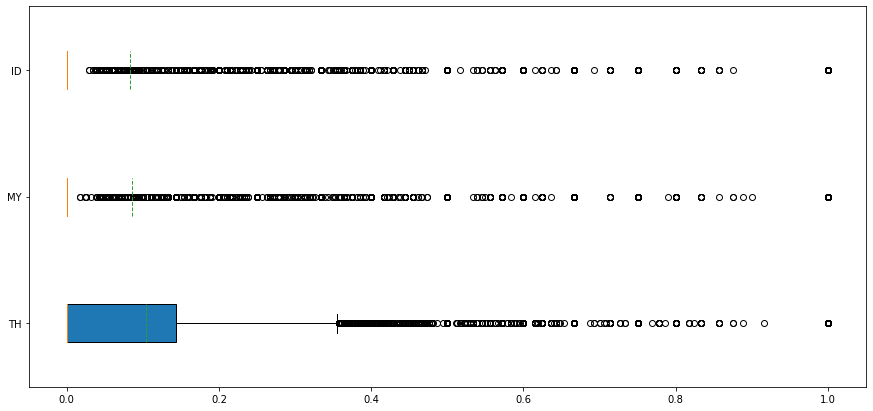

In [37]:
import matplotlib.pyplot as plt

df_th = df[df["warehouse"] == "TH"]["size_dist"]
df_my = df[df["warehouse"] == "MY"]["size_dist"]
df_id = df[df["warehouse"] == "ID"]["size_dist"]

columns = [df_th, df_my, df_id]


fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(111)

ax.boxplot(columns, vert=0, patch_artist=True, meanline=True, showmeans=True)
ax.set_yticklabels(["TH", "MY", "ID"])

plt.show()

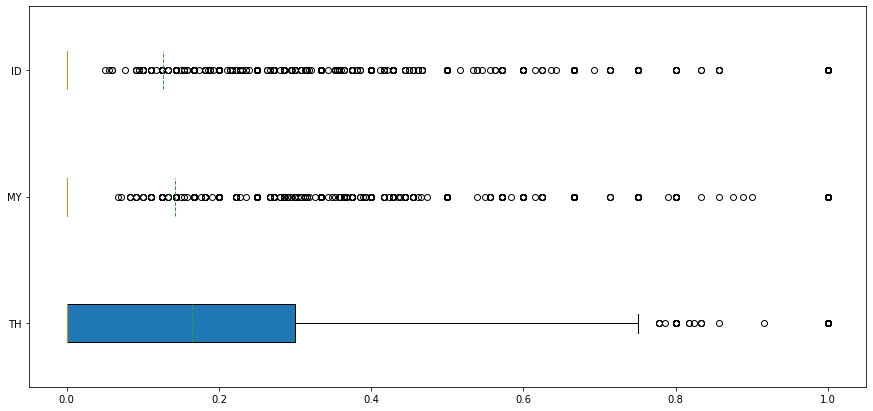

In [38]:
# size S
df_th = df[(df["warehouse"] == "TH") & (df["size"] == "S")]["size_dist"]
df_my = df[(df["warehouse"] == "MY") & (df["size"] == "S")]["size_dist"]
df_id = df[(df["warehouse"] == "ID") & (df["size"] == "S")]["size_dist"]

columns = [df_th, df_my, df_id]


fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(111)

ax.boxplot(columns, vert=0, patch_artist=True, meanline=True, showmeans=True)
ax.set_yticklabels(["TH", "MY", "ID"])

plt.show()

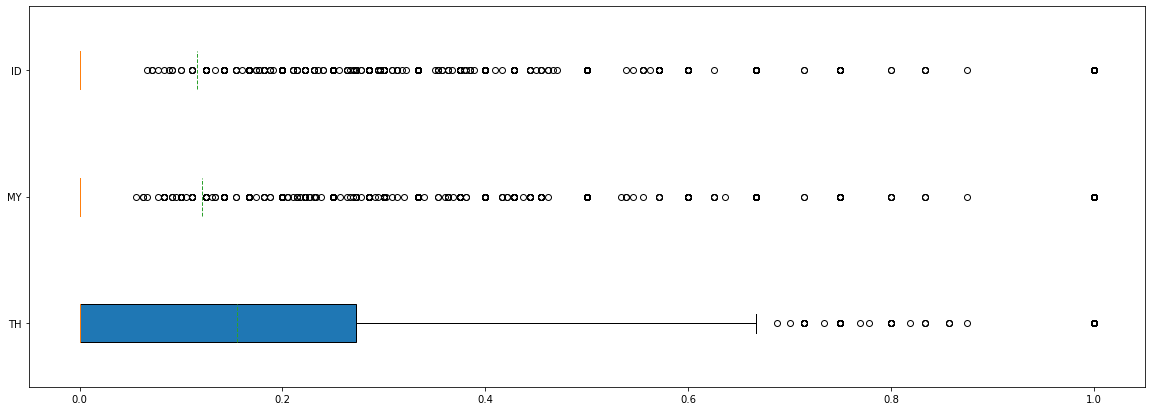

In [39]:
# size M
df_th = df[(df["warehouse"] == "TH") & (df["size"] == "M")]["size_dist"]
df_my = df[(df["warehouse"] == "MY") & (df["size"] == "M")]["size_dist"]
df_id = df[(df["warehouse"] == "ID") & (df["size"] == "M")]["size_dist"]

columns = [df_th, df_my, df_id]


fig = plt.figure(figsize=(20, 7))
ax = fig.add_subplot(111)

ax.boxplot(columns, vert=0, patch_artist=True, meanline=True, showmeans=True)
ax.set_yticklabels(["TH", "MY", "ID"])

plt.show()

<Figure size 600x400 with 0 Axes>

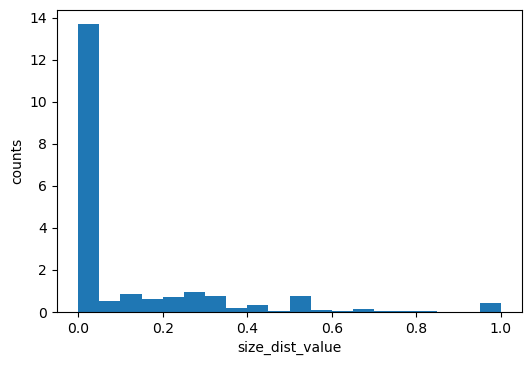

In [40]:
%matplotlib inline
from matplotlib.pyplot import figure

figure(figsize=(6, 4), dpi=100)

x = df[df["warehouse"] == "TH"]["size_dist"]

figure(figsize=(6, 4), dpi=100)
plt.hist(x, density=True, bins=20)  # density=False would make counts
plt.ylabel("counts")
plt.xlabel("size_dist_value");

<Figure size 600x400 with 0 Axes>

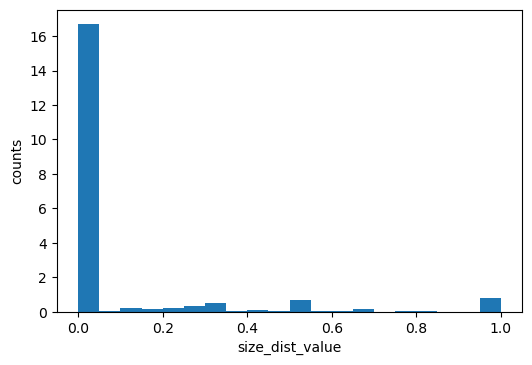

In [41]:
figure(figsize=(6, 4), dpi=100)

x = df[df["warehouse"] == "MY"]["size_dist"]

figure(figsize=(6, 4), dpi=100)
plt.hist(x, density=True, bins=20)  # density=False would make counts
plt.ylabel("counts")
plt.xlabel("size_dist_value");

<Figure size 600x400 with 0 Axes>

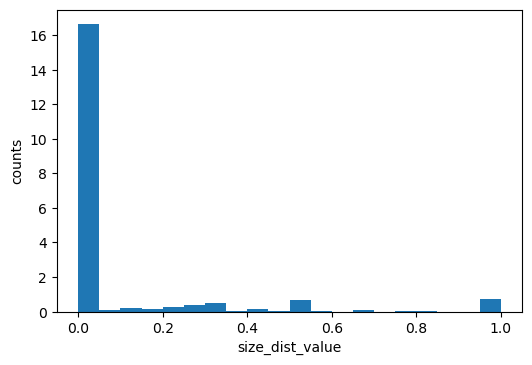

In [42]:
figure(figsize=(6, 4), dpi=100)

x = df[df["warehouse"] == "ID"]["size_dist"]

figure(figsize=(6, 4), dpi=100)
plt.hist(x, density=True, bins=20)  # density=False would make counts
plt.ylabel("counts")
plt.xlabel("size_dist_value");

In [47]:
size_dist_med.to_csv(
    "s3://hal-bi-bucket/data_science/dfm/online_clothing_v2/data/deploy_size_dist_median.csv",
    index=False,
)

In [48]:
size_dist_mean.to_csv(
    "s3://hal-bi-bucket/data_science/dfm/online_clothing_v2/data/deploy_size_dist.csv",
    index=False,
)

In [52]:
dictionary = {
    "week10": "weeks10",
    "week11": "weeks11",
    "week12": "weeks12",
    "week13": "weeks13",
    "week14": "weeks14",
    "week15": "weeks15",
    "week16": "weeks16",
    "week17": "weeks17",
}
for key in dictionary.keys():
    df1["week_id"] = df1["week_id"].replace(key, dictionary[key])

df1 = df1.sort_values(by="week_id")

In [55]:
for key in dictionary.keys():
    size_dist_mean["week_id"] = size_dist_mean["week_id"].replace(key, dictionary[key])

size_dist_mean = size_dist_mean.sort_values(by="week_id")

In [54]:
for s in df1["size"].unique():
    df_plot3 = df1[df1["size"] == s]
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go

    # assign colors to type using a dictionary
    colors = {"mean": "#636EFA", "median": "#EF553B", "q3": "#00CC96"}

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        subplot_titles=("TH", "MY", "ID"),
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "ID"]["size_dist"]["mean"],
            x=df_plot3[df_plot3["warehouse"] == "ID"]["week_id"],
            name="mean_ID",
            marker_color=colors["mean"],
        ),
        row=3,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "ID"]["size_dist"]["median"],
            x=df_plot3[df_plot3["warehouse"] == "ID"]["week_id"],
            name="median_ID",
            marker_color=colors["median"],
        ),
        row=3,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "ID"]["size_dist"]["q3"],
            x=df_plot3[df_plot3["warehouse"] == "ID"]["week_id"],
            name="Q3_ID",
            marker_color=colors["q3"],
        ),
        row=3,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "MY"]["size_dist"]["mean"],
            x=df_plot3[df_plot3["warehouse"] == "MY"]["week_id"],
            name="mean_MY",
            marker_color=colors["mean"],
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "MY"]["size_dist"]["median"],
            x=df_plot3[df_plot3["warehouse"] == "MY"]["week_id"],
            name="median_MY",
            marker_color=colors["median"],
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "MY"]["size_dist"]["q3"],
            x=df_plot3[df_plot3["warehouse"] == "MY"]["week_id"],
            name="Q3_MY",
            marker_color=colors["q3"],
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "TH"]["size_dist"]["mean"],
            x=df_plot3[df_plot3["warehouse"] == "TH"]["week_id"],
            name="mean_TH",
            marker_color=colors["mean"],
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "TH"]["size_dist"]["median"],
            x=df_plot3[df_plot3["warehouse"] == "TH"]["week_id"],
            name="median_TH",
            marker_color=colors["median"],
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot3[df_plot3["warehouse"] == "TH"]["size_dist"]["q3"],
            x=df_plot3[df_plot3["warehouse"] == "TH"]["week_id"],
            name="Q3_TH",
            marker_color=colors["q3"],
        ),
        row=1,
        col=1,
    )

    fig.update_layout(
        height=900, width=1500, title_text=f"size dist mean vs median vs q3 : {s}"
    )

    fig.write_html(
        f"/home/ec2-user/SageMaker/business-intelligence-notebooks/dfm_clothing/online_dfm_v2/plot/size_dist/plot_size_dist_Q_{s}.html"
    )

In [56]:
for s in size_dist_mean["size"].unique():
    df_plot = size_dist_mean[size_dist_mean["size"] == s]
    df_plot2 = size_dist_med[size_dist_med["size"] == s]
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        subplot_titles=("TH", "MY", "ID"),
    )

    fig.add_trace(
        go.Bar(
            y=df_plot[df_plot["warehouse"] == "ID"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "ID"]["week_id"],
            name="size_dist_mean_ID",
        ),
        row=3,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot2[df_plot2["warehouse"] == "ID"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "ID"]["week_id"],
            name="size_dist_median_ID",
        ),
        row=3,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot[df_plot["warehouse"] == "MY"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "MY"]["week_id"],
            name="size_dist_mean_MY",
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot2[df_plot2["warehouse"] == "MY"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "MY"]["week_id"],
            name="size_dist_median_MY",
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot[df_plot["warehouse"] == "TH"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "TH"]["week_id"],
            name="size_dist_mean_TH",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Bar(
            y=df_plot2[df_plot2["warehouse"] == "TH"]["size_dist"],
            x=df_plot[df_plot["warehouse"] == "TH"]["week_id"],
            name="size_dist_median_TH",
        ),
        row=1,
        col=1,
    )

    fig.update_layout(
        height=900, width=1500, title_text=f"size dist mean vs median : {s}"
    )

    fig.write_html(
        f"/home/ec2-user/SageMaker/business-intelligence-notebooks/dfm_clothing/online_dfm_v2/plot/size_dist/plot_size_dist_{s}.html"
    )